# **Requirement 1: Single Campaign and Stochastic Environment**

We model the online advertising bidding problem as a Multi-Armed Bandit (MAB).

At each round $t$, an advertiser:
1. Observes an auction opportunity (an impression).
2. Submits a **bid** $b_t$ from a discrete set of bids $\mathcal{B} = \{b^{(1)}, \ldots, b^{(K)}\}$ (arms).
3. Wins the auction if $b_t$ exceeds the **highest competing bid** $c_t$ (drawn i.i.d. from an unknown distribution $F$).
4. If it wins, it pays $b_t$ (first-price) and receives a **value** $v$ (assumed known for a single campaign).
5. The **reward** is: $r_t = (v - b_t) \cdot \mathbf{1}[b_t \geq c_t]$.

The stochastic environment is a distribution over the highest competing bid $c_t$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Build a Stochastic Environment

The environment samples the highest competing bid $c_t \sim F$ i.i.d. at each discrete time step $t$.

To evaluate the robustness of the learning algorithms, we implement three distinct probability distributions for the competing bids: Uniform, Gaussian (truncated), and Beta.

The action space is discretized into $K$ arms, where each arm $k$ corresponds to a fixed bid value $b^{(k)}$. Under a first-price auction mechanism, when the agent plays arm $k$ with a fixed valuation $v$, the expected reward is:

$$\mu_k = \mathbb{E}_{c \sim F} \left[ (v - b^{(k)}) \cdot \mathbb{I}\{b^{(k)} \geq c\} \right] = (v - b^{(k)}) F(b^{(k)})$$



In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

In [3]:
# Ensure project root is in path for imports
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment


We can design different environments by changing the distribution function of the highest competing bids. 

In [4]:
def uniform_generator(size):
    return np.random.uniform(0.0, 1.0, size=size)

def beta_generator(size, a=2, b = 5):
    # a=2, b=5 creates a right-skewed profile (most competing bids are low)
    return np.random.beta(a, b, size=size)

def clipped_gaussian_generator(size):
    # Mean=0.4, Std=0.15; Clipped strictly to [0, 1] to respect auction bounds
    raw_samples = np.random.normal(loc=0.4, scale=0.15, size=size)
    return np.clip(raw_samples, 0.0, 1.0)


Let's see what these distribution look like for the highest competing bids : 

In [5]:
T = 1000
value = 1.0

env_uniform = SingleCampaignEnvironment(value=value, T=T, distribution_func=uniform_generator)
env_beta    = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
env_gaussian= SingleCampaignEnvironment(value=value, T=T, distribution_func=clipped_gaussian_generator)

# to extract the generated bids from the environment  
m_unif = env_uniform.get_m_sequence().flatten()
m_beta = env_beta.get_m_sequence().flatten()
m_gaus = env_gaussian.get_m_sequence().flatten()

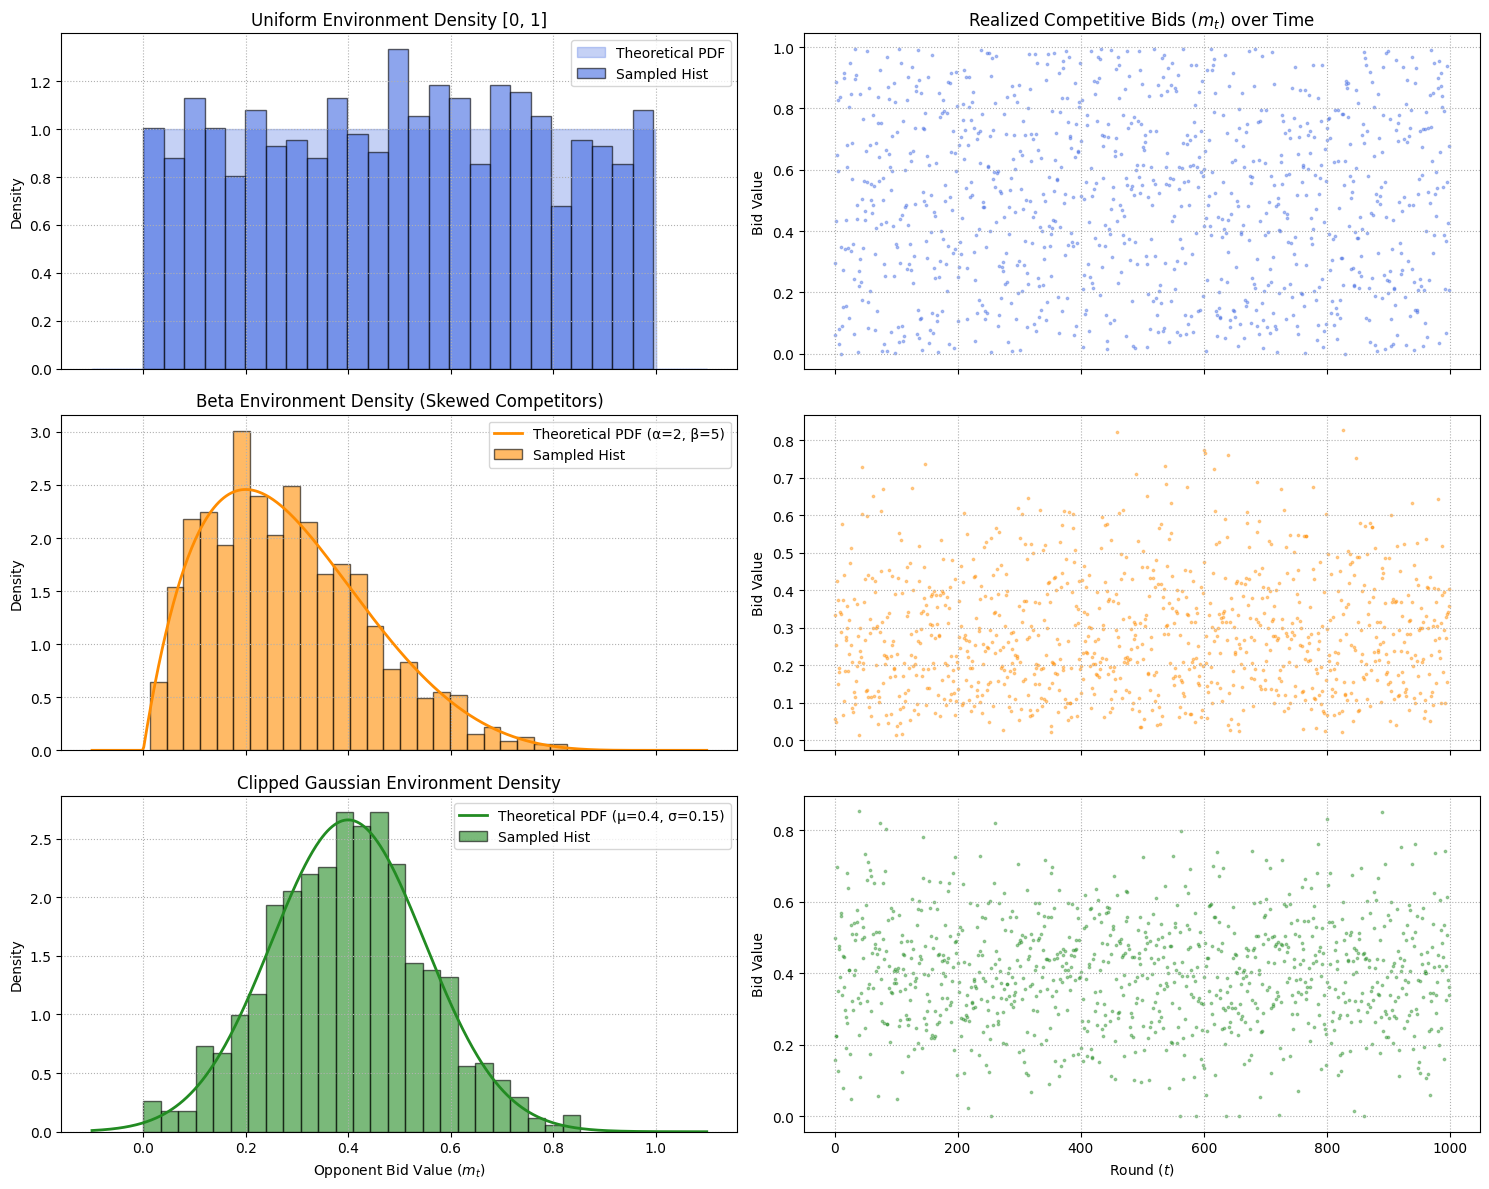

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex='col')

# --- ROW 1: UNIFORM ENVIRONMENT ---
# Theoretical Density
x_axis = np.linspace(-0.1, 1.1, 500)
axes[0, 0].fill_between(x_axis, (x_axis >= 0) & (x_axis <= 1), alpha=0.3, color='royalblue', label='Theoretical PDF')
axes[0, 0].hist(m_unif, bins=25, density=True, alpha=0.6, color='royalblue', edgecolor='black', label='Sampled Hist')
axes[0, 0].set_title('Uniform Environment Density [0, 1]')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=':')

# Realized Sequence over Time
axes[0, 1].scatter(range(T), m_unif, s=3, alpha=0.4, color='royalblue')
axes[0, 1].set_title('Realized Competitive Bids ($m_t$) over Time')
axes[0, 1].set_ylabel('Bid Value')
axes[0, 1].grid(True, linestyle=':')

# --- ROW 2: BETA ENVIRONMENT ---
# Theoretical Density
axes[1, 0].plot(x_axis, beta.pdf(x_axis, 2, 5), color='darkorange', lw=2, label='Theoretical PDF (α=2, β=5)')
axes[1, 0].hist(m_beta, bins=25, density=True, alpha=0.6, color='darkorange', edgecolor='black', label='Sampled Hist')
axes[1, 0].set_title('Beta Environment Density (Skewed Competitors)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=':')

# Realized Sequence over Time
axes[1, 1].scatter(range(T), m_beta, s=3, alpha=0.4, color='darkorange')
axes[1, 1].set_ylabel('Bid Value')
axes[1, 1].grid(True, linestyle=':')

# --- ROW 3: CLIPPED GAUSSIAN ENVIRONMENT ---
# Theoretical Density (Approximated via matching parameters)
axes[2, 0].plot(x_axis, norm.pdf(x_axis, 0.4, 0.15), color='forestgreen', lw=2, label='Theoretical PDF (μ=0.4, σ=0.15)')
axes[2, 0].hist(m_gaus, bins=25, density=True, alpha=0.6, color='forestgreen', edgecolor='black', label='Sampled Hist')
axes[2, 0].set_title('Clipped Gaussian Environment Density')
axes[2, 0].set_xlabel('Opponent Bid Value ($m_t$)')
axes[2, 0].set_ylabel('Density')
axes[2, 0].legend()
axes[2, 0].grid(True, linestyle=':')

# Realized Sequence over Time
axes[2, 1].scatter(range(T), m_gaus, s=3, alpha=0.4, color='forestgreen')
axes[2, 1].set_xlabel('Round ($t$)')
axes[2, 1].set_ylabel('Bid Value')
axes[2, 1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

---
## Part 2: Algorithm 1 — UCB1 Ignoring the Budget Constraint

We treat the bidding problem as a standard MAB: at each round pick the arm with the highest **Upper Confidence Bound**:

$$\text{UCB}_k(t) = \hat{\mu}_k(t) + \sqrt{\frac{2 \ln T}{N_k(t)}}$$

where $\hat{\mu}_k(t)$ is the empirical mean reward of arm $k$ after $N_k(t)$ pulls.

This completely **ignores the budget** — the agent may overspend.

In [7]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Route module lookups to the src directory
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import SingleCampaignUCB1Learner



Let's try out this simple agent for MABs 

## For a uniform distribution : 

In [8]:
T = 10000
K = 11
value = 1.0
bid_space = np.linspace(0.0, 1.0, K)

# 2. Initialization
np.random.seed(42)
env = SingleCampaignEnvironment(value=value, T=T, distribution_func=uniform_generator)
agent = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)

# 3. Tracking Arrays
history_rewards_agent = np.zeros(T)
history_bids_agent = np.zeros(T)
snapshot_t2_means = np.zeros(K)
snapshot_t2_pulls = np.zeros(K)

# 4. Execution Loop
for t in range(T):
    arm_idx = agent.pull_arm()
    b_t = bid_space[arm_idx]
    
    won, utility, cost = env.resolve_auction(b_t)
    agent.update(won, utility, cost)
    
    history_rewards_agent[t] = utility
    history_bids_agent[t] = b_t
    
    if t == (T // 4) - 1:
        snapshot_t2_means = np.copy(agent.average_rewards)
        snapshot_t2_pulls = np.copy(agent.pulls)


In [9]:
# 5. Compute Expected Baselines
# -- Discrete OPT --
sampled_m = uniform_generator(100000)
win_probabilities = np.mean(sampled_m[:, None] <= bid_space, axis=0)
expected_rewards = (value - bid_space) * win_probabilities

OPT_discrete = np.max(expected_rewards)
best_discrete_bid = bid_space[np.argmax(expected_rewards)]

# -- Continuous OPT (Analytical for Uniform U(0,1)) --
OPT_continuous = 0.25
best_continuous_bid = 0.50

In [10]:
# 6. Regret Mathematics & UCB State Calculations
time_steps = np.arange(1, T + 1)
expected_cum_disc = time_steps * OPT_discrete
expected_cum_cont = time_steps * OPT_continuous
cum_rewards_agent = np.cumsum(history_rewards_agent)

regret_vs_disc = expected_cum_disc - cum_rewards_agent
regret_vs_cont = expected_cum_cont - cum_rewards_agent

safe_pulls_t2 = np.maximum(snapshot_t2_pulls, 1.0)
exploration_radius_t2 = np.sqrt(2 * np.log(T / 2) / safe_pulls_t2)
ucb_t2 = snapshot_t2_means + exploration_radius_t2

safe_pulls_T = np.maximum(agent.pulls, 1.0)
exploration_radius_T = np.sqrt(2 * np.log(T) / safe_pulls_T)
ucb_T = agent.average_rewards + exploration_radius_T

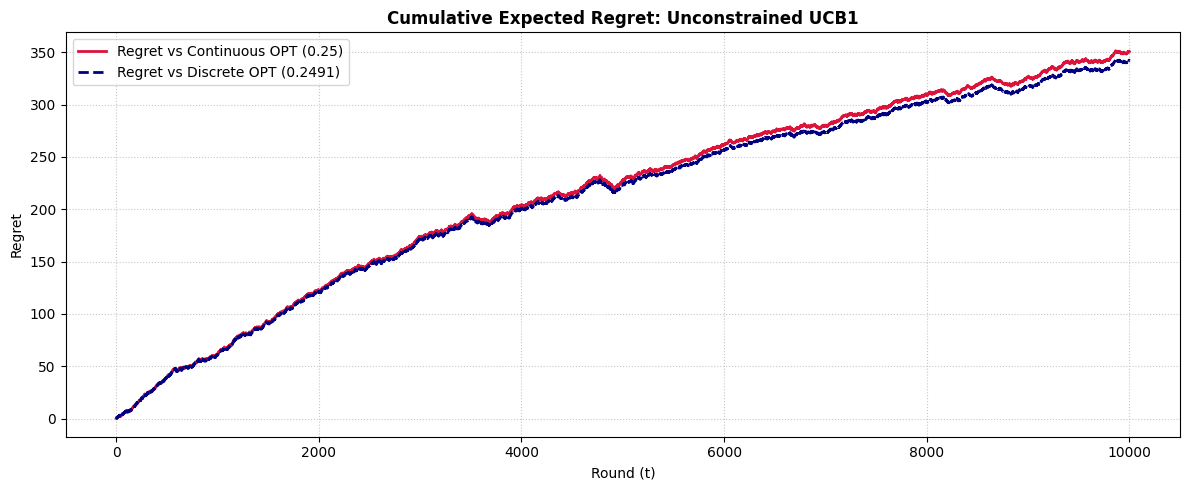

Discrete OPT per round  : 0.2491 (Bid: 0.50)
Continuous OPT per round: 0.2500 (Bid: 0.50)
Final Regret vs Discrete: 342.25


In [11]:

# 7. Visualization
plt.figure(figsize=(12, 5))
plt.plot(time_steps, regret_vs_cont, color='crimson', lw=2, label=f'Regret vs Continuous OPT ({OPT_continuous:.2f})')
plt.plot(time_steps, regret_vs_disc, color='navy', linestyle='--', lw=2, label=f'Regret vs Discrete OPT ({OPT_discrete:.4f})')
plt.title("Cumulative Expected Regret: Unconstrained UCB1", fontweight='bold')
plt.xlabel("Round (t)")
plt.ylabel("Regret")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 8. Terminal Diagnostics
print(f"Discrete OPT per round  : {OPT_discrete:.4f} (Bid: {best_discrete_bid:.2f})")
print(f"Continuous OPT per round: {OPT_continuous:.4f} (Bid: {best_continuous_bid:.2f})")
print(f"Final Regret vs Discrete: {regret_vs_disc[-1]:.2f}")

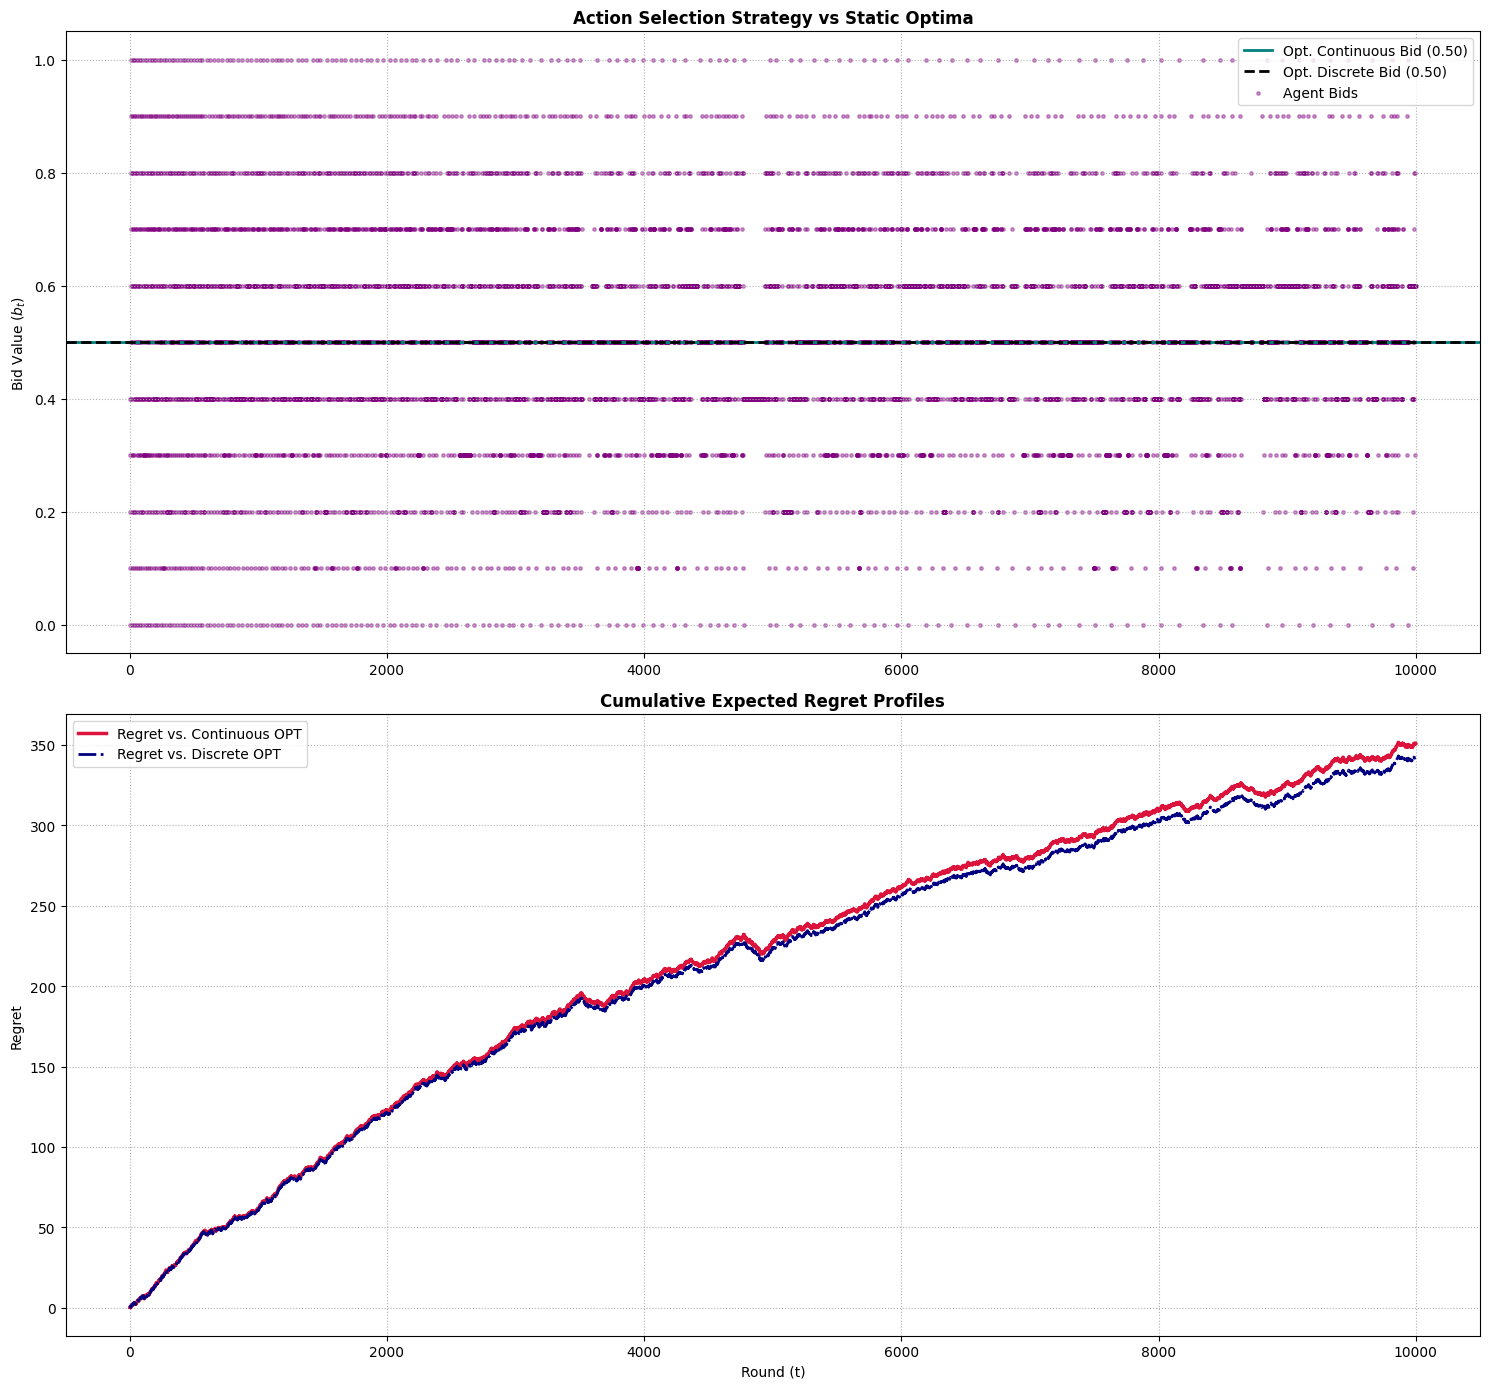

In [12]:
plt.figure(figsize=(15, 14))

# --- PLOT 1: Action Selection ---
plt.subplot(2, 1, 1)
# Static optimal bids are horizontal lines, not scattered points
plt.axhline(y=best_continuous_bid, color='teal', linestyle='-', lw=2, label=f'Opt. Continuous Bid ({best_continuous_bid:.2f})')
plt.axhline(y=best_discrete_bid, color='black', linestyle='--', lw=2, label=f'Opt. Discrete Bid ({best_discrete_bid:.2f})')
plt.scatter(time_steps, history_bids_agent, s=6, color='purple', alpha=0.4, label='Agent Bids')
plt.title('Action Selection Strategy vs Static Optima', fontweight='bold')
plt.ylabel('Bid Value ($b_t$)')
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

# --- PLOT 2: Expected Regret ---
plt.subplot(2, 1, 2)
plt.plot(time_steps, regret_vs_cont, color='crimson', lw=2.5, label='Regret vs. Continuous OPT')
plt.plot(time_steps, regret_vs_disc, color='navy', lw=2, linestyle='-.', label='Regret vs. Discrete OPT')
plt.title('Cumulative Expected Regret Profiles', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Regret')
plt.grid(True, linestyle=':')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

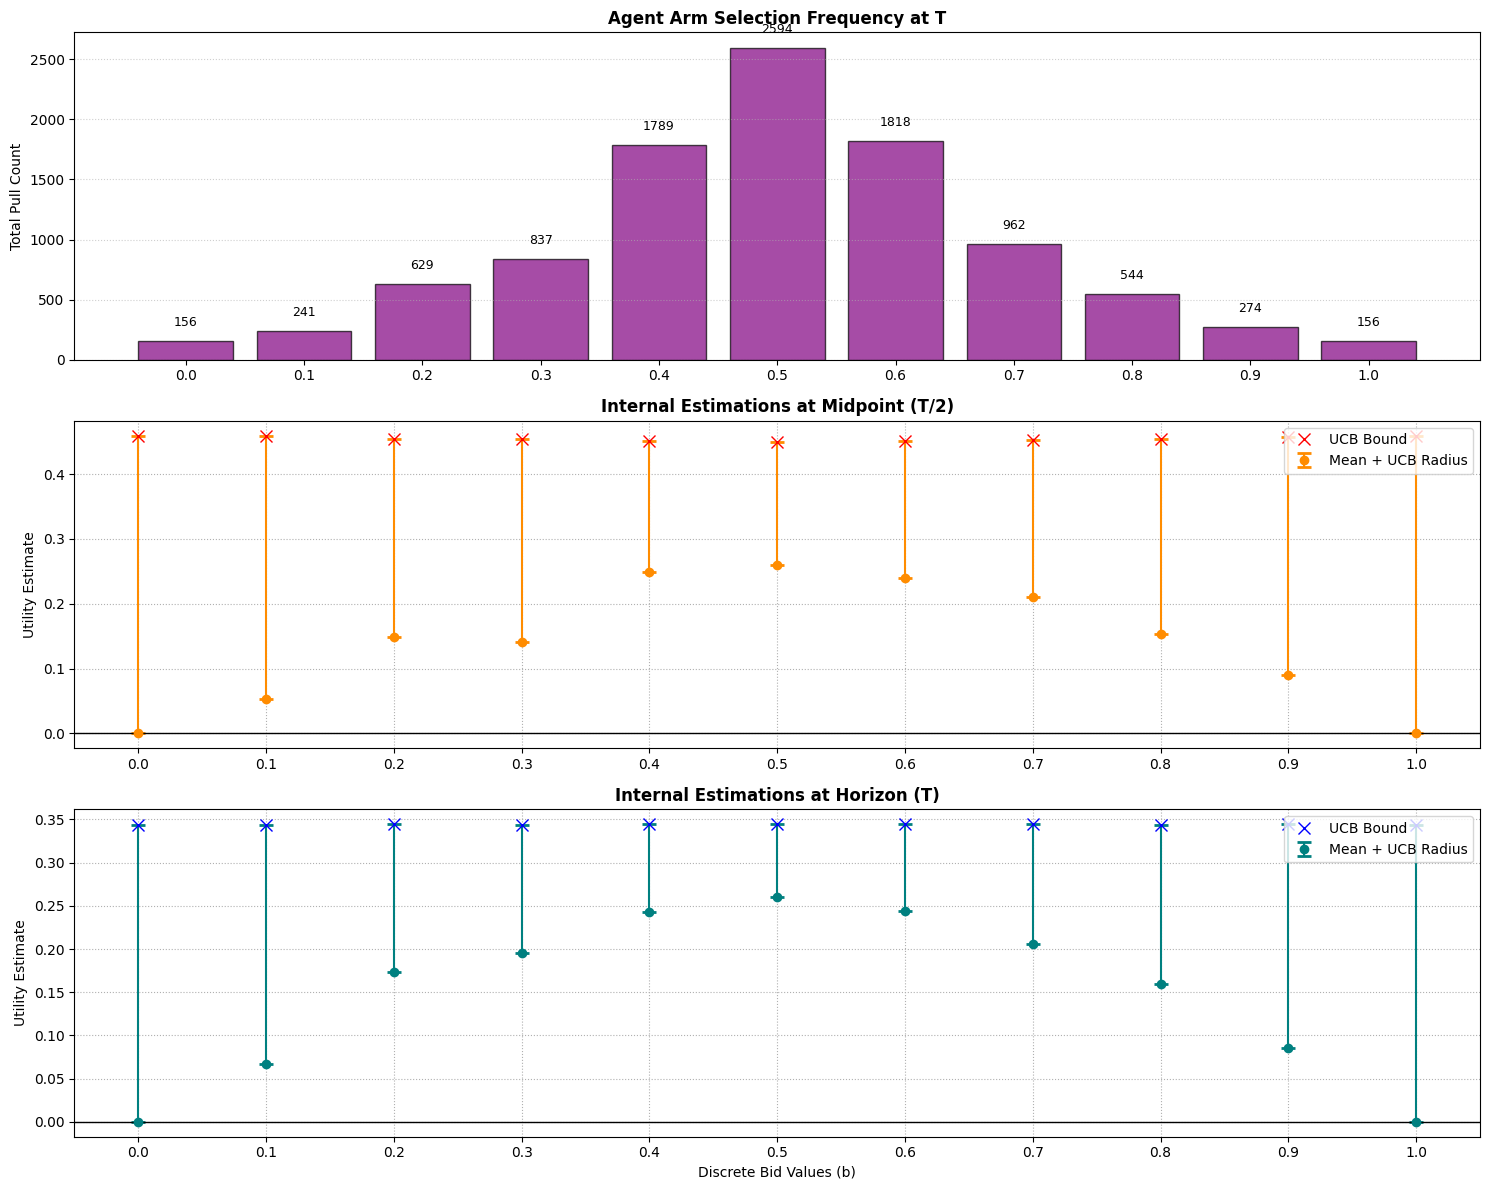

In [13]:
plt.figure(figsize=(15, 12))
arm_indices = np.arange(K)
bid_labels = [f"{b:.1f}" for b in bid_space]
# --- PLOT 1: Arm Selection Frequency ---
plt.subplot(3, 1, 1)
# FIXED: agent.N_pulls -> agent.pulls
bars = plt.bar(arm_indices, agent.pulls, color='purple', edgecolor='black', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (T*0.01), f"{int(yval)}", ha='center', va='bottom', fontsize=9)
plt.title('Agent Arm Selection Frequency at T', fontweight='bold')
plt.ylabel('Total Pull Count')
plt.xticks(arm_indices, bid_labels)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# --- PLOT 2: Internal Estimations at Midpoint (T/2) ---
plt.subplot(3, 1, 2)
plt.errorbar(arm_indices, snapshot_t2_means, yerr=[np.zeros(K), exploration_radius_t2], 
             fmt='o', color='darkorange', capsize=5, capthick=2, label='Mean + UCB Radius')
plt.plot(arm_indices, ucb_t2, 'x', color='red', markersize=8, label='UCB Bound')
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Internal Estimations at Midpoint (T/2)', fontweight='bold')
plt.ylabel('Utility Estimate')
plt.xticks(arm_indices, bid_labels)
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

# --- PLOT 3: Internal Estimations at Horizon (T) ---
plt.subplot(3, 1, 3)
plt.errorbar(arm_indices, agent.average_rewards, yerr=[np.zeros(K), exploration_radius_T], 
             fmt='o', color='teal', capsize=5, capthick=2, label='Mean + UCB Radius')
plt.plot(arm_indices, ucb_T, 'x', color='blue', markersize=8, label='UCB Bound')
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Internal Estimations at Horizon (T)', fontweight='bold')
plt.xlabel('Discrete Bid Values (b)')
plt.ylabel('Utility Estimate')
plt.xticks(arm_indices, bid_labels)
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## For other distributions : 

In [14]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Route module lookups to the src directory
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import SingleCampaignUCB1Learner

Executing Monte Carlo for Uniform...
Executing Monte Carlo for Beta(2,5)...
Executing Monte Carlo for Gaussian(0.4, 0.15)...


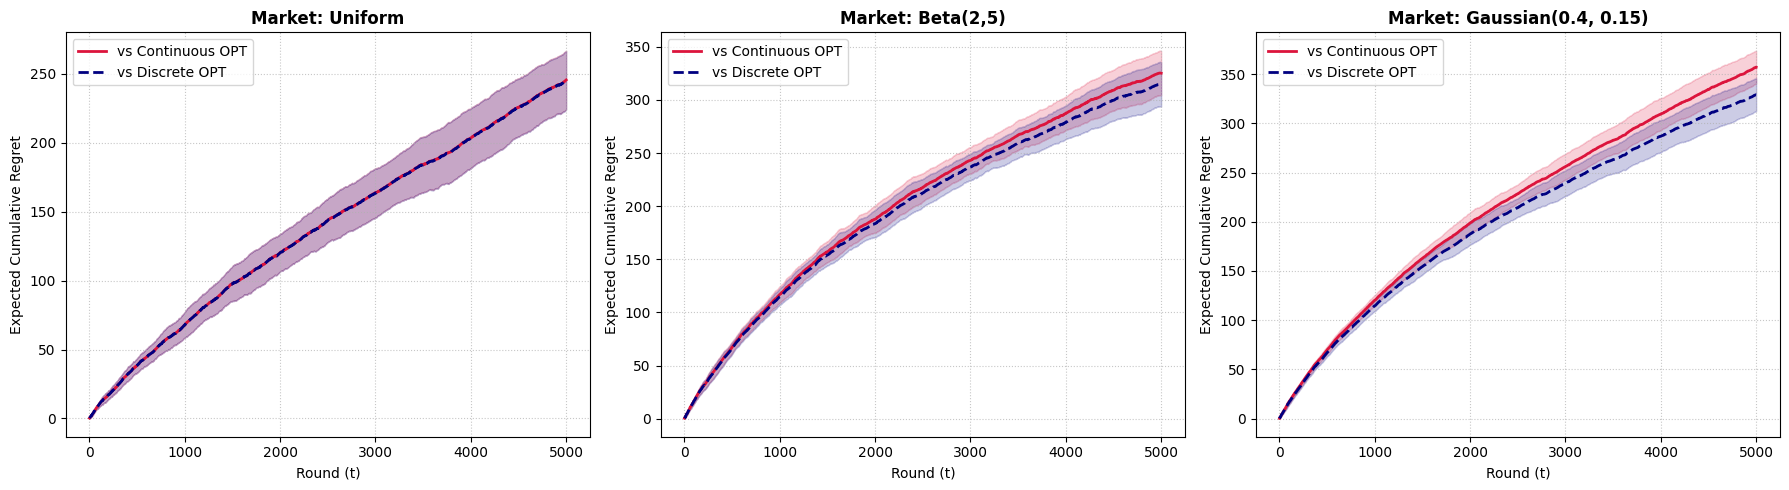

In [15]:


# --- 1. Global Configuration ---
T = 5000
K = 11
N_SIMULATIONS = 20  # Minimum required for statistical significance
value = 1.0
bid_space = np.linspace(0.0, 1.0, K)

environments = {
    'Uniform': uniform_generator,
    'Beta(2,5)': beta_generator,
    'Gaussian(0.4, 0.15)': clipped_gaussian_generator
}

# --- 3. Fluid Baseline Solvers ---
def compute_baselines(generator_func, bid_space, value, sample_size=500000):
    """Numerically computes Discrete and Continuous OPT via Monte Carlo integration."""
    samples = generator_func(sample_size)
    
    # Discrete OPT
    win_probs = np.mean(samples[:, None] <= bid_space, axis=0)
    expected_rewards_disc = (value - bid_space) * win_probs
    OPT_discrete = np.max(expected_rewards_disc)
    
    # Continuous OPT (Numerical Optimization)
    def neg_expected_reward(b):
        if b < 0.0 or b > 1.0: return 0.0
        prob_win = np.mean(samples <= b)
        return -((value - b) * prob_win)
        
    res = minimize_scalar(neg_expected_reward, bounds=(0.0, 1.0), method='bounded')
    OPT_continuous = -res.fun
    
    return OPT_discrete, OPT_continuous

# --- 4. Execution Engine ---
results = {}

for env_name, gen_func in environments.items():
    print(f"Executing Monte Carlo for {env_name}...")
    OPT_disc, OPT_cont = compute_baselines(gen_func, bid_space, value)
    
    # Matrices to hold multiple trajectories
    regret_matrix_disc = np.zeros((N_SIMULATIONS, T))
    regret_matrix_cont = np.zeros((N_SIMULATIONS, T))
    
    for sim in range(N_SIMULATIONS):
        env = SingleCampaignEnvironment(value=value, T=T, distribution_func=gen_func)
        agent = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
        
        trajectory_rewards = np.zeros(T)
        
        for t in range(T):
            arm_idx = agent.pull_arm()
            b_t = bid_space[arm_idx]
            won, utility, cost = env.resolve_auction(b_t)
            agent.update(won, utility, cost)
            trajectory_rewards[t] = utility
            
        cum_rewards = np.cumsum(trajectory_rewards)
        time_steps = np.arange(1, T + 1)
        
        regret_matrix_disc[sim, :] = (time_steps * OPT_disc) - cum_rewards
        regret_matrix_cont[sim, :] = (time_steps * OPT_cont) - cum_rewards

    results[env_name] = {
        'mean_regret_disc': np.mean(regret_matrix_disc, axis=0),
        'std_regret_disc': np.std(regret_matrix_disc, axis=0),
        'mean_regret_cont': np.mean(regret_matrix_cont, axis=0),
        'std_regret_cont': np.std(regret_matrix_cont, axis=0)
    }

# --- 5. Visualization ---
time_steps = np.arange(1, T + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (env_name, data) in enumerate(results.items()):
    ax = axes[idx]
    
    # Continuous Regret
    ax.plot(time_steps, data['mean_regret_cont'], color='crimson', lw=2, label='vs Continuous OPT')
    ax.fill_between(time_steps, 
                    data['mean_regret_cont'] - data['std_regret_cont'], 
                    data['mean_regret_cont'] + data['std_regret_cont'], 
                    color='crimson', alpha=0.2)
    
    # Discrete Regret
    ax.plot(time_steps, data['mean_regret_disc'], color='navy', linestyle='--', lw=2, label='vs Discrete OPT')
    ax.fill_between(time_steps, 
                    data['mean_regret_disc'] - data['std_regret_disc'], 
                    data['mean_regret_disc'] + data['std_regret_disc'], 
                    color='navy', alpha=0.2)

    ax.set_title(f'Market: {env_name}', fontweight='bold')
    ax.set_xlabel('Round (t)')
    ax.set_ylabel('Expected Cumulative Regret')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

We can try a variant of the UCB-bidding algorithm : 

Computing theoretical baselines via Monte Carlo integration...
OPT_discrete:   0.4603
OPT_continuous: 0.4622

Executing paired simulation 0/5...


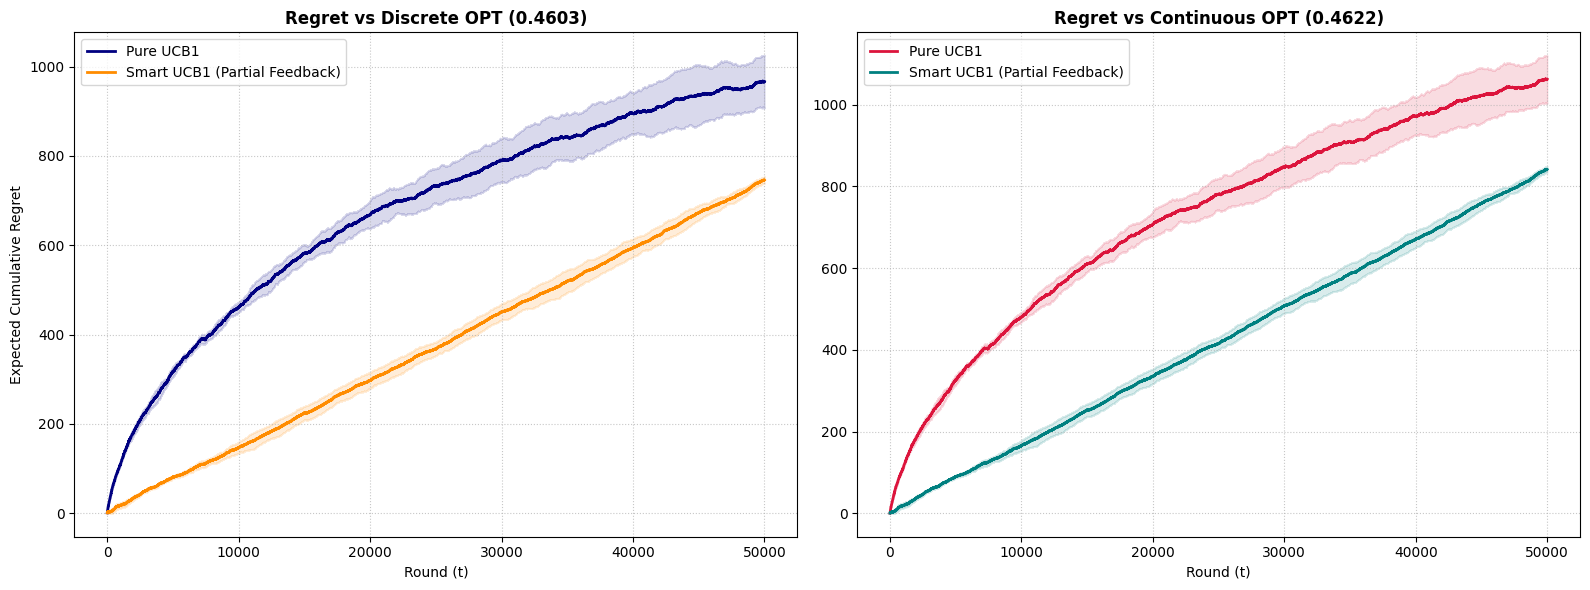

In [16]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import SingleCampaignUCB1Learner, SmartUCB1Agent

# 1. Configuration
T = 50000
K = 11
N_SIMULATIONS = 5
value = 1.0
bid_space = np.linspace(0.0, 1.0, K)

# Beta Distribution Parameters
# alpha < beta: Right-skewed (mostly low competing bids)
# alpha > beta: Left-skewed (mostly high competing bids)
ALPHA = 2.0 
BETA = 5.0

def target_generator(size):
    return np.random.beta(ALPHA, BETA, size=size)

# 2. Compute Fluid Baselines
print("Computing theoretical baselines via Monte Carlo integration...")
samples = target_generator(500000)
win_probs = np.mean(samples[:, None] <= bid_space, axis=0)
expected_rewards_disc = (value - bid_space) * win_probs
OPT_disc = np.max(expected_rewards_disc)

def neg_expected_reward(b):
    if b < 0.0 or b > 1.0: return 0.0
    return -((value - b) * np.mean(samples <= b))

OPT_cont = -minimize_scalar(neg_expected_reward, bounds=(0.0, 1.0), method='bounded').fun

print(f"OPT_discrete:   {OPT_disc:.4f}")
print(f"OPT_continuous: {OPT_cont:.4f}\n")

# 3. Execution Engine
regret_disc_pure = np.zeros((N_SIMULATIONS, T))
regret_cont_pure = np.zeros((N_SIMULATIONS, T))
regret_disc_smart = np.zeros((N_SIMULATIONS, T))
regret_cont_smart = np.zeros((N_SIMULATIONS, T))

for sim in range(N_SIMULATIONS):
    if sim % 5 == 0:
        print(f"Executing paired simulation {sim}/{N_SIMULATIONS}...")
        
    # Instantiate Environments and Agents
    env_pure = SingleCampaignEnvironment(value=value, T=T, distribution_func=target_generator)
    env_smart = SingleCampaignEnvironment(value=value, T=T, distribution_func=target_generator)
    
    agent_pure = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
    agent_smart = SmartUCB1Agent(value=value, bid_space=bid_space)
    
    traj_pure = np.zeros(T)
    traj_smart = np.zeros(T)
    
    for t in range(T):
        # Pure Agent Execution
        arm_pure = agent_pure.pull_arm()
        b_pure = bid_space[arm_pure]
        won_p, util_p, cost_p = env_pure.resolve_auction(b_pure)
        agent_pure.update(won_p, util_p, cost_p)
        traj_pure[t] = util_p
        
        # Smart Agent Execution
        arm_smart = agent_smart.pull_arm()
        b_smart = bid_space[arm_smart]
        won_s, util_s, cost_s = env_smart.resolve_auction(b_smart)
        agent_smart.update(won_s, util_s, cost_s)
        traj_smart[t] = util_s
        
    # Calculate Cumulative Regret
    time_steps = np.arange(1, T + 1)
    
    regret_disc_pure[sim, :] = (time_steps * OPT_disc) - np.cumsum(traj_pure)
    regret_cont_pure[sim, :] = (time_steps * OPT_cont) - np.cumsum(traj_pure)
    
    regret_disc_smart[sim, :] = (time_steps * OPT_disc) - np.cumsum(traj_smart)
    regret_cont_smart[sim, :] = (time_steps * OPT_cont) - np.cumsum(traj_smart)

# 4. Statistical Aggregation
mean_disc_pure, std_disc_pure = np.mean(regret_disc_pure, axis=0), np.std(regret_disc_pure, axis=0)
mean_cont_pure, std_cont_pure = np.mean(regret_cont_pure, axis=0), np.std(regret_cont_pure, axis=0)

mean_disc_smart, std_disc_smart = np.mean(regret_disc_smart, axis=0), np.std(regret_disc_smart, axis=0)
mean_cont_smart, std_cont_smart = np.mean(regret_cont_smart, axis=0), np.std(regret_cont_smart, axis=0)

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Regret vs Discrete OPT
axes[0].plot(time_steps, mean_disc_pure, color='navy', lw=2, label='Pure UCB1')
axes[0].fill_between(time_steps, mean_disc_pure - std_disc_pure, mean_disc_pure + std_disc_pure, color='navy', alpha=0.15)
axes[0].plot(time_steps, mean_disc_smart, color='darkorange', lw=2, label='Smart UCB1 (Partial Feedback)')
axes[0].fill_between(time_steps, mean_disc_smart - std_disc_smart, mean_disc_smart + std_disc_smart, color='darkorange', alpha=0.15)
axes[0].set_title(f'Regret vs Discrete OPT ({OPT_disc:.4f})', fontweight='bold')
axes[0].set_xlabel('Round (t)')
axes[0].set_ylabel('Expected Cumulative Regret')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='upper left')

# Plot 2: Regret vs Continuous OPT
axes[1].plot(time_steps, mean_cont_pure, color='crimson', lw=2, label='Pure UCB1')
axes[1].fill_between(time_steps, mean_cont_pure - std_cont_pure, mean_cont_pure + std_cont_pure, color='crimson', alpha=0.15)
axes[1].plot(time_steps, mean_cont_smart, color='teal', lw=2, label='Smart UCB1 (Partial Feedback)')
axes[1].fill_between(time_steps, mean_cont_smart - std_cont_smart, mean_cont_smart + std_cont_smart, color='teal', alpha=0.15)
axes[1].set_title(f'Regret vs Continuous OPT ({OPT_cont:.4f})', fontweight='bold')
axes[1].set_xlabel('Round (t)')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

# UCB-bidding Algo 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Route module lookups to the src directory
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import SingleCampaignBaseLearner, SingleCampaignUCB1Learner, SmartUCB1Agent, BudgetConstrainedUCBAgent, HeuristicBudgetUCBAgent

In [18]:
from src.learners import AvgCostBudgetUCBAgent

## Without Budget Constraint : 

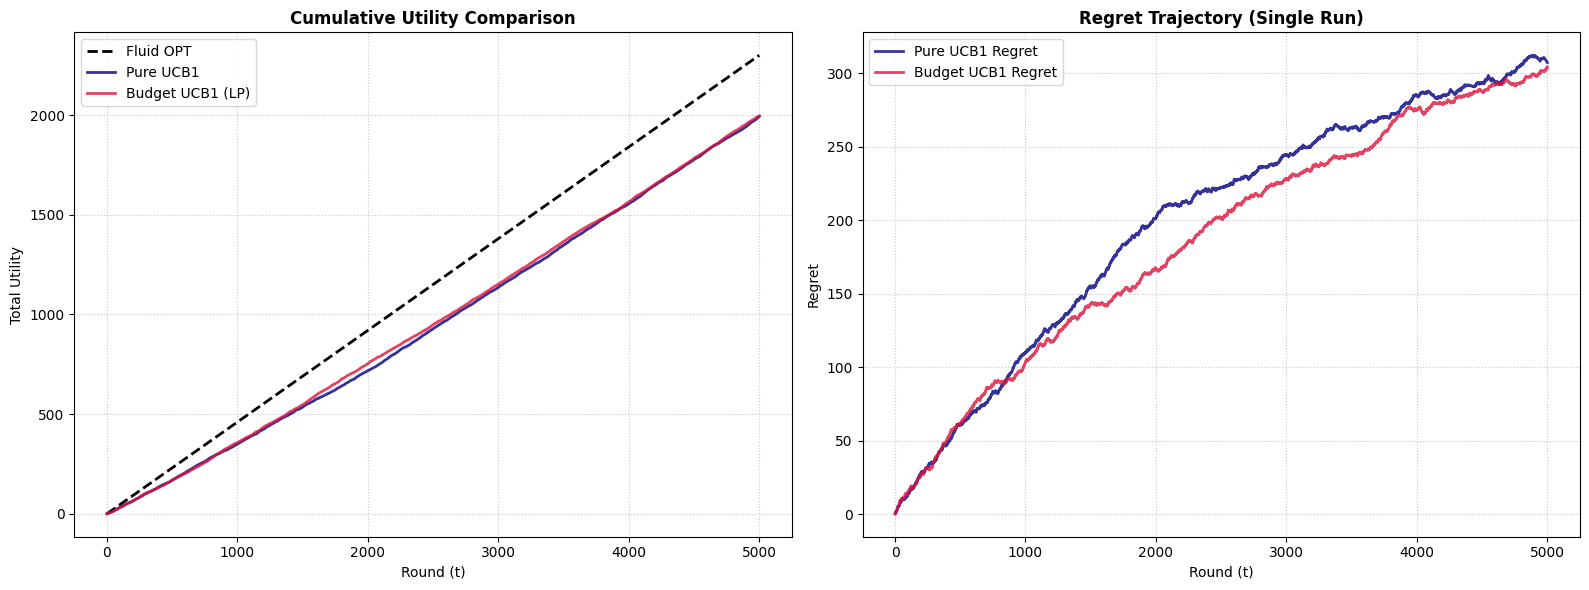

In [19]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog


# 1. System Configuration
T = 5000
K = 11
value = 1.0
B = float(T)  # Non-binding budget constraint
rho = B / T
bid_space = np.linspace(0.0, 1.0, K)

alpha_param = 2
beta_param = 5

def beta_generator(size):
    return np.random.beta(alpha_param, beta_param, size=size)

# 2. Expected Fluid Baseline (OPT)
win_probabilities = beta.cdf(bid_space, a=alpha_param, b=beta_param)
expected_rewards = (value - bid_space) * win_probabilities
expected_costs = bid_space * win_probabilities

c_obj_base = -expected_rewards
A_ub_base = expected_costs.reshape(1, -1)
b_ub_base = np.array([rho])
A_eq_base = np.ones((1, K))
b_eq_base = np.array([1.0])
bounds_base = [(0, 1) for _ in range(K)]

res_base = linprog(c_obj_base, A_ub=A_ub_base, b_ub=b_ub_base, A_eq=A_eq_base, b_eq=b_eq_base, bounds=bounds_base, method='highs')
gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)

OPT = np.sum(gamma_opt * expected_rewards)

# 3. Initialization
np.random.seed(42)
env_base = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
env_budget = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)

agent_base = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
agent_budget = BudgetConstrainedUCBAgent(value=value, bid_space=bid_space, B=B, T=T)

rewards_base = np.zeros(T)
rewards_budget = np.zeros(T)
costs_budget = np.zeros(T)

# 4. Execution Loop (Strictly T iterations)
for t in range(T):
    # Pure UCB Execution
    arm_base = agent_base.pull_arm()
    b_base = bid_space[arm_base]
    won_base, util_base, cost_base = env_base.resolve_auction(b_base)
    agent_base.update(won_base, util_base, cost_base)
    rewards_base[t] = util_base
    
    # Budget UCB Execution
    arm_budget = agent_budget.pull_arm()
    b_budget = bid_space[arm_budget]
    won_budg, util_budg, cost_budg = env_budget.resolve_auction(b_budget)
    agent_budget.update(won_budg, util_budg, cost_budg)
    rewards_budget[t] = util_budg
    costs_budget[t] = cost_budg

# 5. Metrics & Regret
time_steps = np.arange(1, T + 1)
expected_cumulative_baseline = time_steps * OPT

cum_rewards_base = np.cumsum(rewards_base)
cum_rewards_budget = np.cumsum(rewards_budget)

regret_base = expected_cumulative_baseline - cum_rewards_base
regret_budget = expected_cumulative_baseline - cum_rewards_budget

# 6. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(time_steps, expected_cumulative_baseline, color='black', lw=2, linestyle='--', label=r'Fluid OPT')
axes[0].plot(time_steps, cum_rewards_base, color='navy', lw=2, alpha=0.8, label='Pure UCB1')
axes[0].plot(time_steps, cum_rewards_budget, color='crimson', lw=2, alpha=0.8, label='Budget UCB1 (LP)')
axes[0].set_title('Cumulative Utility Comparison', fontweight='bold')
axes[0].set_xlabel('Round (t)')
axes[0].set_ylabel('Total Utility')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend()

axes[1].plot(time_steps, regret_base, color='navy', lw=2, alpha=0.8, label='Pure UCB1 Regret')
axes[1].plot(time_steps, regret_budget, color='crimson', lw=2, alpha=0.8, label='Budget UCB1 Regret')
axes[1].set_title('Regret Trajectory (Single Run)', fontweight='bold')
axes[1].set_xlabel('Round (t)')
axes[1].set_ylabel('Regret')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# 1. Statistical Configuration
N_SIMULATIONS = 30

regret_matrix_base = np.zeros((N_SIMULATIONS, T))
regret_matrix_budget = np.zeros((N_SIMULATIONS, T))

print(f"Executing Monte Carlo Suite: N={N_SIMULATIONS}, T={T}, B={B}")

for sim in range(N_SIMULATIONS):
    if sim % 5 == 0:
        print(f"Running simulation {sim}/{N_SIMULATIONS}...")
        
    env_b = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
    env_c = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
    
    ag_base = SingleCampaignUCB1Learner(value=value, bid_space=bid_space)
    ag_budg = BudgetConstrainedUCBAgent(value=value, bid_space=bid_space, B=B, T=T)
    
    traj_base = np.zeros(T)
    traj_budg = np.zeros(T)
    
    for t in range(T):
        arm_b = ag_base.pull_arm()
        won_b, util_b, cost_b = env_b.resolve_auction(bid_space[arm_b])
        ag_base.update(won_b, util_b, cost_b)
        traj_base[t] = util_b
        
        arm_c = ag_budg.pull_arm()
        won_c, util_c, cost_c = env_c.resolve_auction(bid_space[arm_c])
        ag_budg.update(won_c, util_c, cost_c)
        traj_budg[t] = util_c
        
    regret_matrix_base[sim, :] = expected_cumulative_baseline - np.cumsum(traj_base)
    regret_matrix_budget[sim, :] = expected_cumulative_baseline - np.cumsum(traj_budg)

# 2. Aggregation
mean_regret_base = np.mean(regret_matrix_base, axis=0)
std_regret_base = np.std(regret_matrix_base, axis=0)

mean_regret_budget = np.mean(regret_matrix_budget, axis=0)
std_regret_budget = np.std(regret_matrix_budget, axis=0)

# 3. Visualization
plt.figure(figsize=(10, 6))

plt.plot(time_steps, mean_regret_base, color='navy', lw=2, label='Pure UCB1')
plt.fill_between(time_steps, mean_regret_base - std_regret_base, mean_regret_base + std_regret_base, color='navy', alpha=0.2)

plt.plot(time_steps, mean_regret_budget, color='crimson', lw=2, label='Budget UCB1 (LP)')
plt.fill_between(time_steps, mean_regret_budget - std_regret_budget, mean_regret_budget + std_regret_budget, color='crimson', alpha=0.2)

plt.title(f'Expected Regret Convergence ($N={N_SIMULATIONS}$)', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Expected Cumulative Regret')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Executing Monte Carlo Suite: N=30, T=5000, B=5000.0
Running simulation 0/30...
Running simulation 5/30...
Running simulation 10/30...


KeyboardInterrupt: 

## With Budget Constraint : 

### 1 trajectory

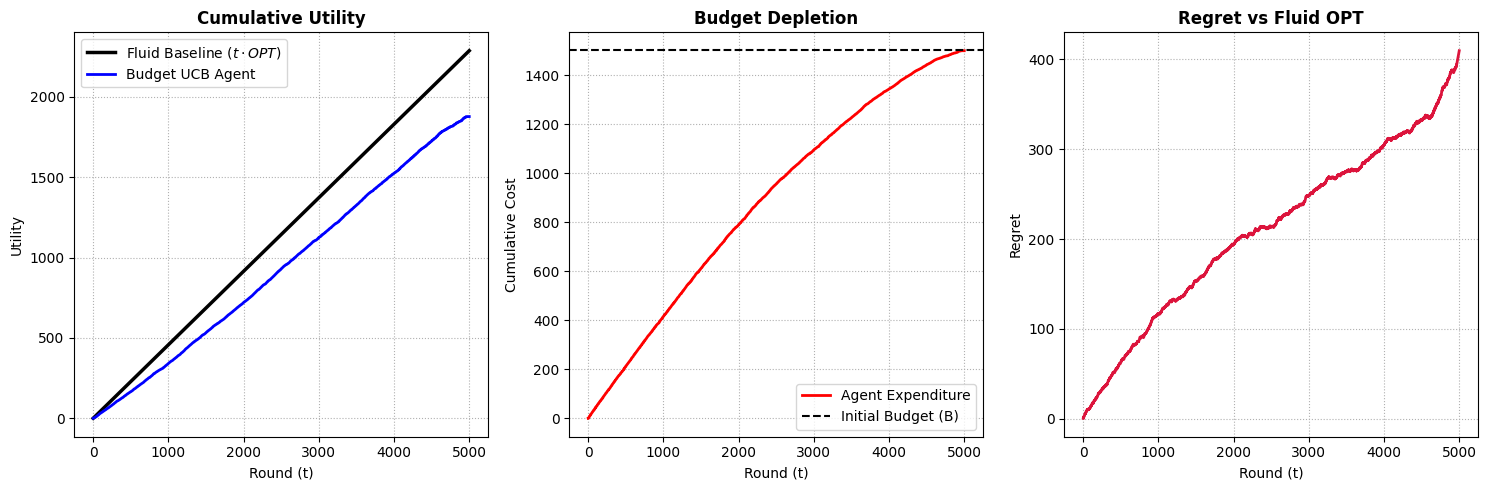

Rounds Played             : 5000 / 5000
Budget Remaining          : 0.90 / 1500.0
Optimal Expected (OPT)    : 0.4573 per round
Terminal Regret           : 409.62


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

# 1. System Configuration
T = 5000
K = 11
value = 1.0
B = 0.3*T # Binding budget constraint
rho = B / T
bid_space = np.linspace(0.0, 1.0, K)

alpha_param = 2
beta_param = 5

def beta_generator(size):
    return np.random.beta(alpha_param, beta_param, size=size)

# 2. Expected Fluid Baseline (OPT)
win_probabilities = beta.cdf(bid_space, a=alpha_param, b=beta_param)
expected_rewards = (value - bid_space) * win_probabilities
expected_costs = bid_space * win_probabilities

c_obj_base = -expected_rewards
A_ub_base = expected_costs.reshape(1, -1)
b_ub_base = np.array([rho])
A_eq_base = np.ones((1, K))
b_eq_base = np.array([1.0])
bounds_base = [(0, 1) for _ in range(K)]

res_base = linprog(c_obj_base, A_ub=A_ub_base, b_ub=b_ub_base, A_eq=A_eq_base, b_eq=b_eq_base, bounds=bounds_base, method='highs-ds')
gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)

OPT = np.sum(gamma_opt * expected_rewards)

# 3. Initialization
np.random.seed(42)
env = SingleCampaignEnvironment(value=value, T=T, distribution_func=beta_generator)
agent = BudgetConstrainedUCBAgent(value=value, bid_space=bid_space, B=B, T=T)

rewards_agent = np.zeros(T)
costs_agent = np.zeros(T)

# 4. Execution Loop (Strictly T iterations)
for t in range(T):
    arm_idx = agent.pull_arm()
    b_t = bid_space[arm_idx] # CRITICAL: Map index to float bid
    
    won, utility, cost = env.resolve_auction(b_t)
    
    agent.update(won, utility, cost) # CRITICAL: Adhere to signature
    
    rewards_agent[t] = utility
    costs_agent[t] = cost

# 5. Metrics & Regret
time_steps = np.arange(1, T + 1)
expected_cumulative_baseline = time_steps * OPT

cum_rewards_agent = np.cumsum(rewards_agent)
cum_costs_agent = np.cumsum(costs_agent)

regret = expected_cumulative_baseline - cum_rewards_agent

# 6. Plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(time_steps, expected_cumulative_baseline, color='black', lw=2.5, label=r'Fluid Baseline ($t \cdot OPT$)')
plt.plot(time_steps, cum_rewards_agent, color='blue', lw=2, label='Budget UCB Agent')
plt.title('Cumulative Utility', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Utility')
plt.grid(True, linestyle=':')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(time_steps, cum_costs_agent, color='red', lw=2, label='Agent Expenditure')
plt.axhline(y=B, color='black', linestyle='--', label='Initial Budget (B)')
plt.title('Budget Depletion', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Cumulative Cost')
plt.grid(True, linestyle=':')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(time_steps, regret, color='crimson', lw=2)
plt.title('Regret vs Fluid OPT', fontweight='bold')
plt.xlabel('Round (t)')
plt.ylabel('Regret')
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

# 7. Terminal Outputs
print(f"Rounds Played             : {T} / {T}")
print(f"Budget Remaining          : {B - cum_costs_agent[-1]:.2f} / {B}")
print(f"Optimal Expected (OPT)    : {OPT:.4f} per round")
print(f"Terminal Regret           : {regret[-1]:.2f}")

### Tests on different Env settings : 

[A - Loose budget (non-binding)]  T=3000  K=11  B=2400.00 (rho=0.8000)  fluid OPT/round=0.4600  N_SIM=10
  sim 0/10...
  sim 2/10...
  sim 4/10...
  sim 6/10...
  sim 8/10...
  saved -> setting_A.png


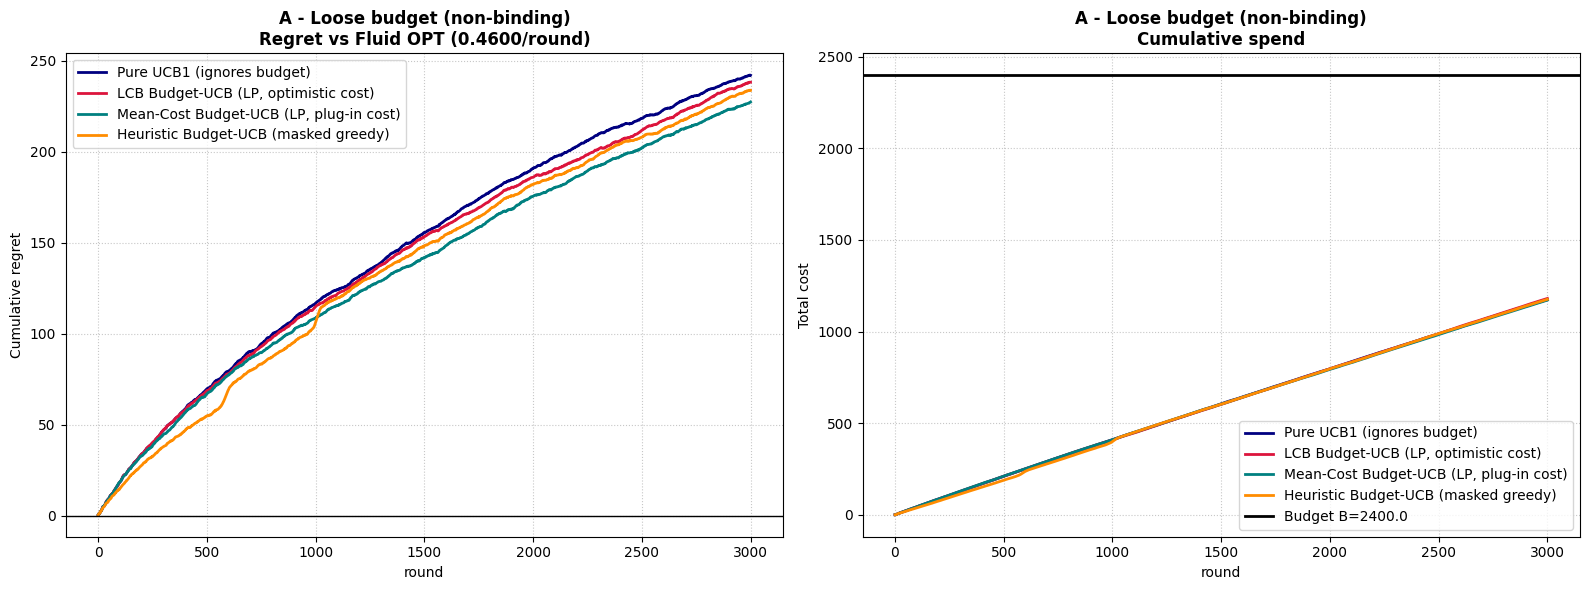

  --- final numbers ---
    Pure UCB1 (ignores budget)                 final cost= 1174.30 / B=2400.00   final regret=   242.10
    LCB Budget-UCB (LP, optimistic cost)       final cost= 1180.67 / B=2400.00   final regret=   238.27
    Mean-Cost Budget-UCB (LP, plug-in cost)    final cost= 1171.90 / B=2400.00   final regret=   227.40
    Heuristic Budget-UCB (masked greedy)       final cost= 1176.05 / B=2400.00   final regret=   233.85

[B - Binding budget, easy-to-win distribution]  T=3000  K=11  B=900.00 (rho=0.3000)  fluid OPT/round=0.4573  N_SIM=10
  sim 0/10...
  sim 2/10...
  sim 4/10...
  sim 6/10...
  sim 8/10...
  saved -> setting_B.png


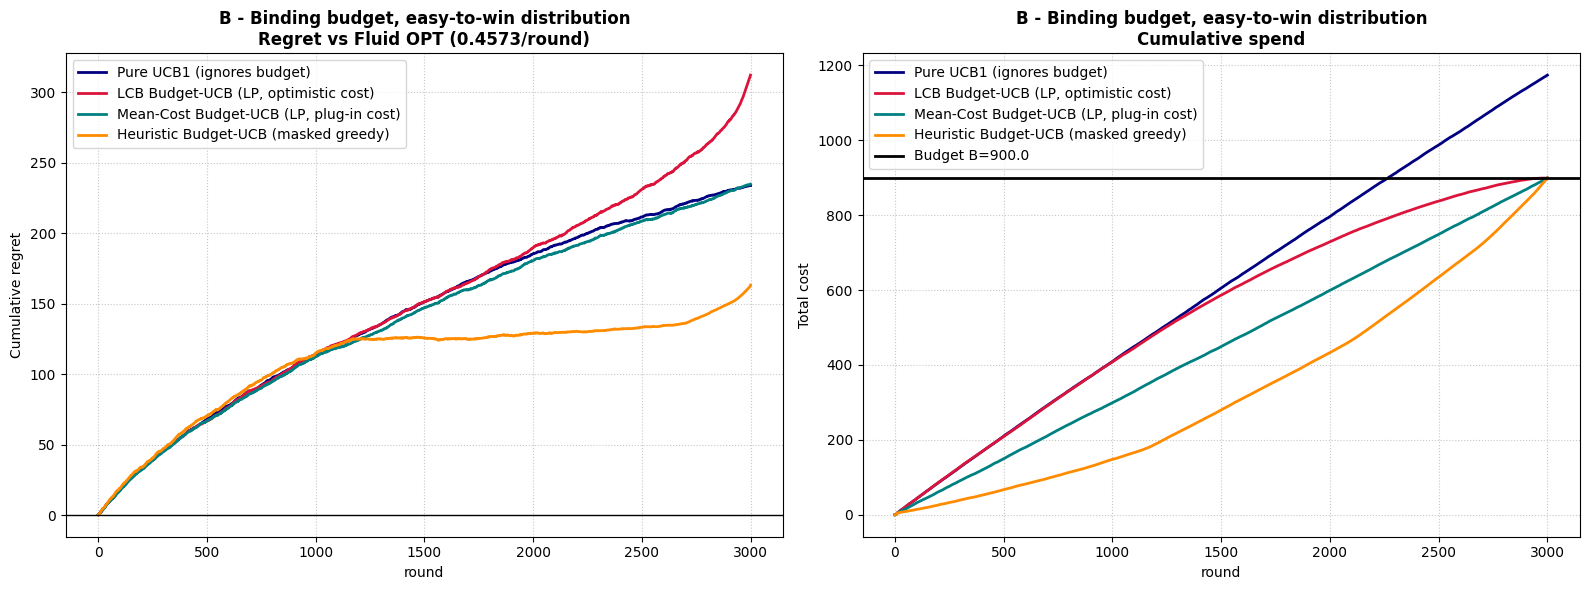

  --- final numbers ---
    Pure UCB1 (ignores budget)                 final cost= 1174.30 / B= 900.00   final regret=   233.91
    LCB Budget-UCB (LP, optimistic cost)       final cost=  899.18 / B= 900.00   final regret=   312.19
    Mean-Cost Budget-UCB (LP, plug-in cost)    final cost=  900.04 / B= 900.00   final regret=   234.85
    Heuristic Budget-UCB (masked greedy)       final cost=  899.22 / B= 900.00   final regret=   163.23

[C - Scarce budget, hard-to-win distribution]  T=3000  K=11  B=240.00 (rho=0.0800)  fluid OPT/round=0.0662  N_SIM=10
  sim 0/10...
  sim 2/10...
  sim 4/10...
  sim 6/10...
  sim 8/10...
  saved -> setting_C.png


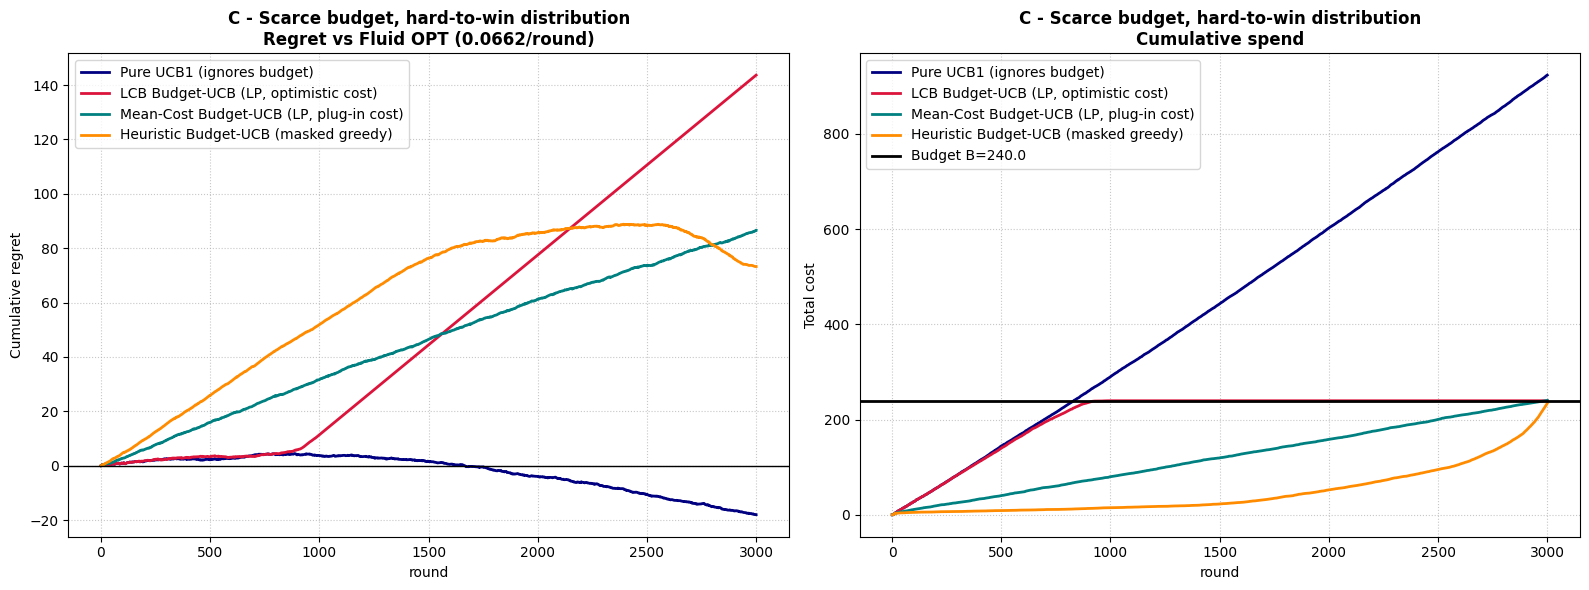

  --- final numbers ---
    Pure UCB1 (ignores budget)                 final cost=  923.63 / B= 240.00   final regret=   -18.01
    LCB Budget-UCB (LP, optimistic cost)       final cost=  239.49 / B= 240.00   final regret=   143.65
    Mean-Cost Budget-UCB (LP, plug-in cost)    final cost=  240.13 / B= 240.00   final regret=    86.59
    Heuristic Budget-UCB (masked greedy)       final cost=  234.10 / B= 240.00   final regret=    73.26



In [23]:
"""
Requirement 1 -- comparison of all four single-campaign learners across
three settings
  A) Loose / non-binding budget      
  B) Binding budget
  C) Scarce budget  
  
"""

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import (
    SingleCampaignUCB1Learner,
    BudgetConstrainedUCBAgent,
    AvgCostBudgetUCBAgent,
    HeuristicBudgetUCBAgent,
)

AGENT_KEYS = ['base', 'lp', 'mc', 'heur']
LABELS = {
    'base': 'Pure UCB1 (ignores budget)',
    'lp':   'LCB Budget-UCB (LP, optimistic cost)',
    'mc':   'Mean-Cost Budget-UCB (LP, plug-in cost)',
    'heur': 'Heuristic Budget-UCB (masked greedy)',
}
COLORS = {'base': 'navy', 'lp': 'crimson', 'mc': 'teal', 'heur': 'darkorange'}


def make_agents(value, bid_space, B, T):
    return {
        'base': SingleCampaignUCB1Learner(value, bid_space),
        'lp':   BudgetConstrainedUCBAgent(value, bid_space, B, T),
        'mc':   AvgCostBudgetUCBAgent(value, bid_space, B, T),
        'heur': HeuristicBudgetUCBAgent(value, bid_space, B, T),
    }


def compute_fluid_opt(value, bid_space, rho, alpha_param, beta_param):
    """Same fluid-relaxation LP as your example: best fixed randomized bid
    respecting the average per-round budget rho, given the distribution of mt"""
    win_probs = beta.cdf(bid_space, a=alpha_param, b=beta_param)
    exp_rewards = (value - bid_space) * win_probs
    exp_costs = bid_space * win_probs
    res = linprog(
        -exp_rewards,
        A_ub=exp_costs.reshape(1, -1), b_ub=np.array([rho]),
        A_eq=np.ones((1, len(bid_space))), b_eq=np.array([1.0]),
        bounds=[(0, 1) for _ in bid_space], method='highs-ds'
    )
    gamma_opt = np.clip(res.x, 0, 1)
    gamma_opt /= np.sum(gamma_opt)
    return float(np.sum(gamma_opt * exp_rewards))


def run_experiment(name, T, K, N_SIMULATIONS, value, B, alpha_param, beta_param, seed0=0):
    bid_space = np.linspace(0.0, 1.0, K)   # includes 0 -- required by all 3 budget agents
    rho = B / T
    OPT = compute_fluid_opt(value, bid_space, rho, alpha_param, beta_param)
    time_steps = np.arange(1, T + 1)
    expected_cumulative_baseline = time_steps * OPT

    metrics = {k: {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))}
               for k in AGENT_KEYS}

    print(f"[{name}]  T={T}  K={K}  B={B:.2f} (rho={rho:.4f})  fluid OPT/round={OPT:.4f}  N_SIM={N_SIMULATIONS}")

    for sim in range(N_SIMULATIONS):
        if sim % max(1, N_SIMULATIONS // 5) == 0:
            print(f"  sim {sim}/{N_SIMULATIONS}...")

        np.random.seed(seed0 + sim)
        # common random numbers: draw ONE m_sequence and reuse it for every
        # agent this replicate, so differences in the plots are due to the
        # algorithms, not to each agent facing different auctions
        m_sequence = np.random.beta(alpha_param, beta_param, size=T)
        shared_dist = lambda size, _seq=m_sequence: _seq.copy()

        envs = {k: SingleCampaignEnvironment(value, T, shared_dist) for k in AGENT_KEYS}
        agents = make_agents(value, bid_space, B, T)
        traj = {k: {'util': np.zeros(T), 'cost': np.zeros(T)} for k in AGENT_KEYS}

        for t in range(T):
            for k in AGENT_KEYS:
                arm = agents[k].pull_arm()
                won, util, cost = envs[k].resolve_auction(bid_space[arm])
                agents[k].update(won, util, cost)
                traj[k]['util'][t] = util
                traj[k]['cost'][t] = cost

        for k in AGENT_KEYS:
            metrics[k]['regret'][sim, :] = expected_cumulative_baseline - np.cumsum(traj[k]['util'])
            metrics[k]['cost'][sim, :] = np.cumsum(traj[k]['cost'])

    return metrics, time_steps, OPT


def plot_experiment(name, metrics, time_steps, OPT, B, savepath=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for k in AGENT_KEYS:
        mean_regret = np.mean(metrics[k]['regret'], axis=0)
        axes[0].plot(time_steps, mean_regret, color=COLORS[k], lw=2, label=LABELS[k])

        mean_cost = np.mean(metrics[k]['cost'], axis=0)
        axes[1].plot(time_steps, mean_cost, color=COLORS[k], lw=2, label=LABELS[k])

    axes[0].axhline(0, color='black', lw=1)
    axes[0].set_title(f'{name}\nRegret vs Fluid OPT ({OPT:.4f}/round)', fontweight='bold')
    axes[0].set_xlabel('round'); axes[0].set_ylabel('Cumulative regret')
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.7)

    axes[1].axhline(B, color='black', lw=2, linestyle='-', label=f'Budget B={B:.1f}')
    axes[1].set_title(f'{name}\nCumulative spend', fontweight='bold')
    axes[1].set_xlabel('round'); axes[1].set_ylabel('Total cost')
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
        print(f"  saved -> {savepath}")
    plt.show()


# ----------------------------------------------------------------------
# Three settings, deliberately chosen to be different regimes, not just
# different numbers:
#   A: budget is generous              -> budget-aware agents should track
#                                          plain UCB1 almost exactly
#   B: budget genuinely binds, but the
#      distribution makes winning easy -> the "normal" pacing case
#   C: budget is scarce AND winning
#      requires higher bids            -> tests graceful degradation once
#                                          the hard-stop kicks in early
# ----------------------------------------------------------------------
SETTINGS = [
    dict(name="A - Loose budget (non-binding)",
         T=3000, K=11, N_SIMULATIONS=10, value=1.0,
         B_frac=0.8, alpha_param=2, beta_param=5),
    dict(name="B - Binding budget, easy-to-win distribution",
         T=3000, K=11, N_SIMULATIONS=10, value=1.0,
         B_frac=0.30, alpha_param=2, beta_param=5),
    dict(name="C - Scarce budget, hard-to-win distribution",
         T=3000, K=11, N_SIMULATIONS=10, value=1.0,
         B_frac=0.08, alpha_param=5, beta_param=2),
]

if __name__ == "__main__":
    for cfg in SETTINGS:
        T, K, N_SIM, value = cfg['T'], cfg['K'], cfg['N_SIMULATIONS'], cfg['value']
        B = cfg['B_frac'] * T
        metrics, time_steps, OPT = run_experiment(
            cfg['name'], T, K, N_SIM, value, B, cfg['alpha_param'], cfg['beta_param']
        )
        savepath = f"setting_{cfg['name'][0]}.png"
        plot_experiment(cfg['name'], metrics, time_steps, OPT, B, savepath=savepath)

        print("  --- final numbers ---")
        for k in AGENT_KEYS:
            final_cost = np.mean(metrics[k]['cost'], axis=0)[-1]
            final_regret = np.mean(metrics[k]['regret'], axis=0)[-1]
            print(f"    {LABELS[k]:42s} final cost={final_cost:8.2f} / B={B:7.2f}   final regret={final_regret:9.2f}")
        print()


Executing Setting 1: Loose Budget & Low Competition (Right-Skewed)


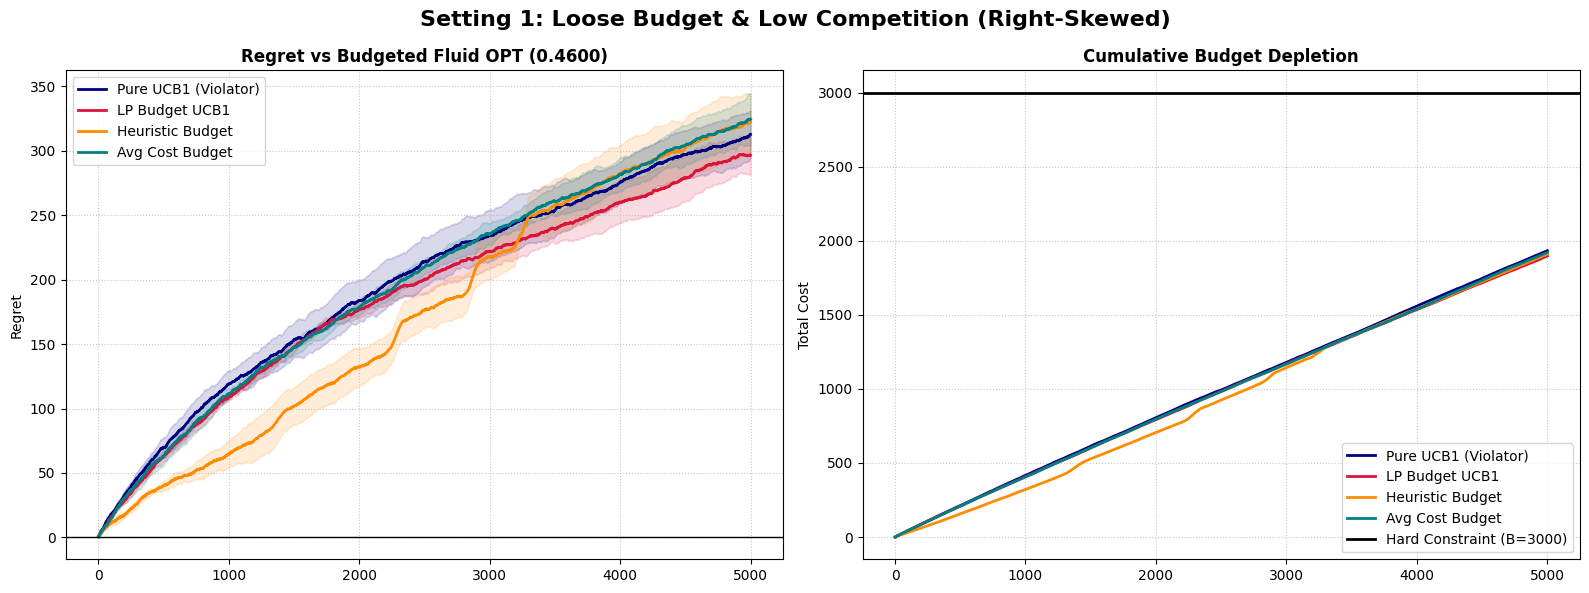


Executing Setting 2: Tight Budget & High Competition (Left-Skewed)


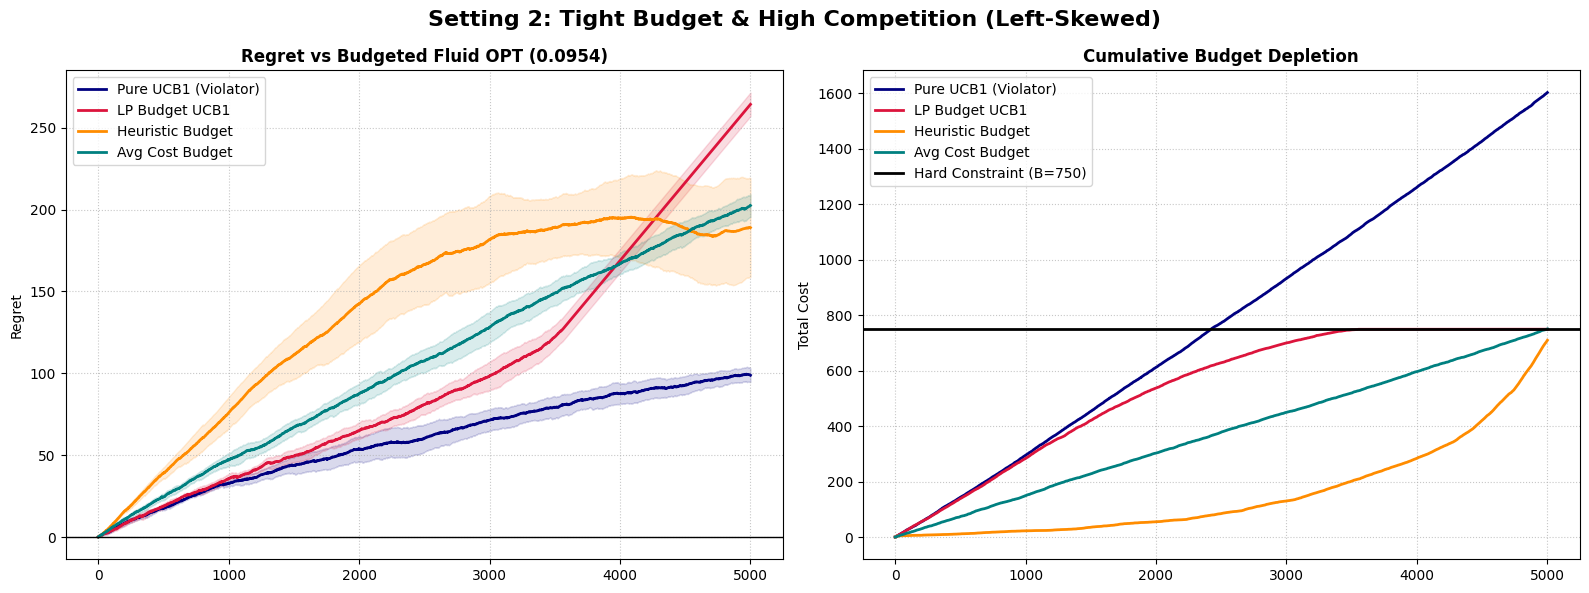


Executing Setting 3: Moderate Budget & Bimodal Market (U-Shape)


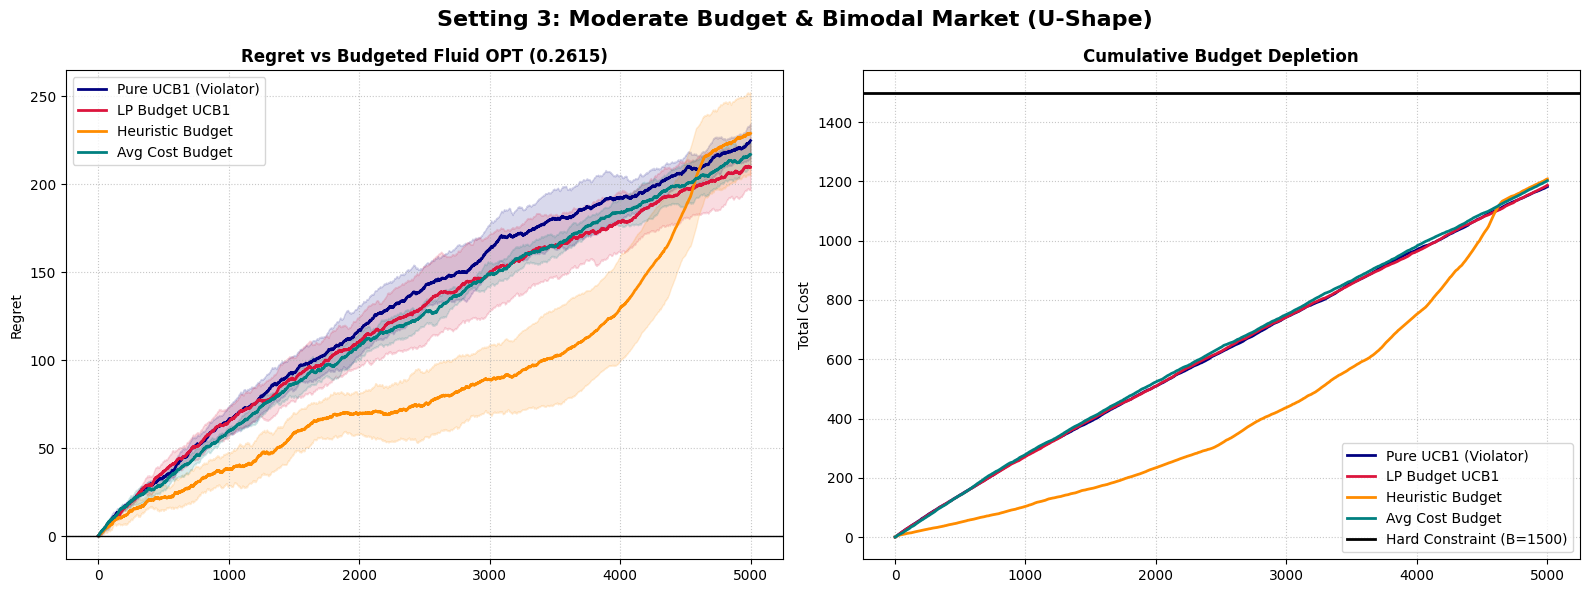

In [25]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import (
    SingleCampaignUCB1Learner, 
    BudgetConstrainedUCBAgent, 
    HeuristicBudgetUCBAgent,
    AvgCostBudgetUCBAgent
)

# 1. Global Configuration
T = 5000
K = 11
N_SIMULATIONS = 5
value = 1.0
bid_space = np.linspace(0.0, 1.0, K)
time_steps = np.arange(1, T + 1)

agent_keys = ['base', 'lp', 'heur', 'MC']
colors = {'base': 'navy', 'lp': 'crimson', 'heur': 'darkorange', 'MC': 'teal'}
labels = {
    'base': 'Pure UCB1 (Violator)', 
    'lp': 'LP Budget UCB1', 
    'heur': 'Heuristic Budget', 
    'MC': 'Avg Cost Budget'
}

# 2. Experimental Scenarios
# Setting 1: High Budget, Low Competition. Constraint is non-binding. Tests if LP defaults to pure UCB.
# Setting 2: Tight Budget, High Competition. Forces sparse bidding. Heuristics usually fail here.
# Setting 3: Bimodal Market. Bids cluster at 0 or 1. Tests if LP identifies extreme mixed strategies.
settings = [
    {"name": "Setting 1: Loose Budget & Low Competition (Right-Skewed)", "alpha": 2.0, "beta": 5.0, "B_frac": 0.6},
    {"name": "Setting 2: Tight Budget & High Competition (Left-Skewed)", "alpha": 5.0, "beta": 2.0, "B_frac": 0.15},
    {"name": "Setting 3: Moderate Budget & Bimodal Market (U-Shape)", "alpha": 0.5, "beta": 0.5, "B_frac": 0.3}
]

def run_simulation(config):
    print(f"\n{'='*60}\nExecuting {config['name']}\n{'='*60}")
    
    B = config['B_frac'] * T
    rho = B / T
    alpha_param = config['alpha']
    beta_param = config['beta']
    
    def beta_generator(size):
        return np.random.beta(alpha_param, beta_param, size=size)
        
    # Fluid OPT Calculation
    win_probs = beta.cdf(bid_space, a=alpha_param, b=beta_param)
    exp_rewards = (value - bid_space) * win_probs
    exp_costs = bid_space * win_probs

    res_base = linprog(
        -exp_rewards, 
        A_ub=exp_costs.reshape(1, -1), b_ub=np.array([rho]), 
        A_eq=np.ones((1, K)), b_eq=np.array([1.0]), 
        bounds=[(0, 1) for _ in range(K)], method='highs-ds'
    )
    
    gamma_opt = np.clip(res_base.x, 0, 1)
    gamma_opt /= np.sum(gamma_opt)
    OPT_budget = np.sum(gamma_opt * exp_rewards)
    expected_cumulative_baseline = time_steps * OPT_budget

    metrics = {k: {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))} for k in agent_keys}

    # Execution Loop
    for sim in range(N_SIMULATIONS):
        envs = {key: SingleCampaignEnvironment(value, T, beta_generator) for key in agent_keys}
        
        agents = {
            'base': SingleCampaignUCB1Learner(value, bid_space),
            'lp': BudgetConstrainedUCBAgent(value, bid_space, B, T),
            'heur': HeuristicBudgetUCBAgent(value, bid_space, B, T),
            'MC': AvgCostBudgetUCBAgent(value, bid_space, B, T)
        }
        
        trajectories = {key: {'util': np.zeros(T), 'cost': np.zeros(T)} for key in agent_keys}
        
        for t in range(T):
            for key in agent_keys:
                arm = agents[key].pull_arm()
                won, util, cost = envs[key].resolve_auction(bid_space[arm])
                agents[key].update(won, util, cost)
                
                trajectories[key]['util'][t] = util
                trajectories[key]['cost'][t] = cost
                
        for key in agent_keys:
            metrics[key]['regret'][sim, :] = expected_cumulative_baseline - np.cumsum(trajectories[key]['util'])
            metrics[key]['cost'][sim, :] = np.cumsum(trajectories[key]['cost'])

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for key in agent_keys:
        mean_regret = np.mean(metrics[key]['regret'], axis=0)
        std_regret = np.std(metrics[key]['regret'], axis=0)
        mean_cost = np.mean(metrics[key]['cost'], axis=0)
        
        axes[0].plot(time_steps, mean_regret, color=colors[key], lw=2, label=labels[key])
        axes[0].fill_between(time_steps, mean_regret - std_regret, mean_regret + std_regret, color=colors[key], alpha=0.15)
        axes[1].plot(time_steps, mean_cost, color=colors[key], lw=2, label=labels[key])

    axes[0].axhline(0, color='black', lw=1)
    axes[0].set_title(f'Regret vs Budgeted Fluid OPT ({OPT_budget:.4f})', fontweight='bold')
    axes[0].set_ylabel('Regret')
    axes[0].legend()
    axes[0].grid(True, linestyle=':', alpha=0.7)

    axes[1].axhline(B, color='black', lw=2, linestyle='-', label=f'Hard Constraint (B={B:.0f})')
    axes[1].set_title('Cumulative Budget Depletion', fontweight='bold')
    axes[1].set_ylabel('Total Cost')
    axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.7)

    fig.suptitle(config['name'], fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 3. Execute all configurations
for config in settings:
    run_simulation(config)


Executing setting 2 


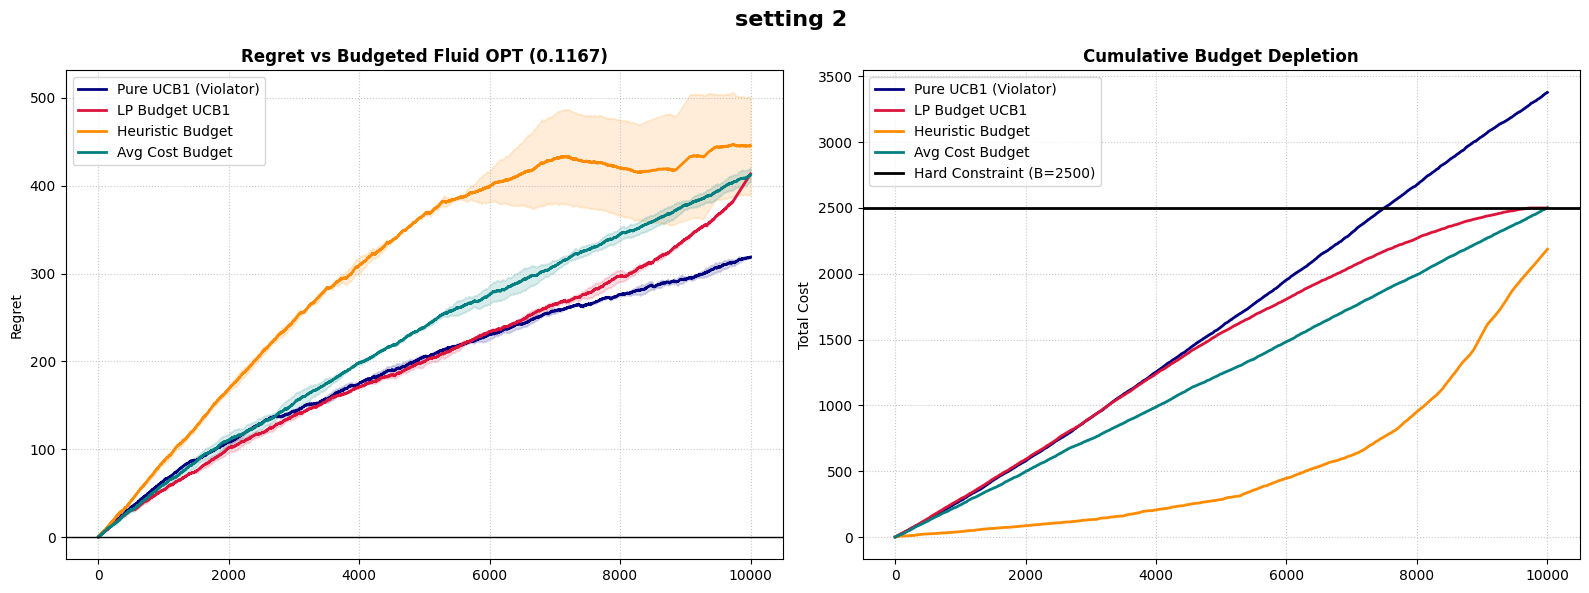

In [26]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import linprog

sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment
from src.learners import (
    SingleCampaignUCB1Learner, 
    BudgetConstrainedUCBAgent, 
    HeuristicBudgetUCBAgent,
    AvgCostBudgetUCBAgent
)

# ==========================================
# 1. TUNABLE PARAMETERS (Setting 2 Default)
# ==========================================
SETTING_NAME = "setting 2 "
ALPHA_PARAM = 5.0
BETA_PARAM = 2.0
B_FRAC = 0.25

T = 10000
K = 11
N_SIMULATIONS = 2
VALUE = 1.0

# ==========================================
# 2. INITIALIZATION
# ==========================================
bid_space = np.linspace(0.0, 1.0, K)
time_steps = np.arange(1, T + 1)
B = B_FRAC * T
rho = B / T

agent_keys = ['base', 'lp', 'heur', 'MC']
colors = {'base': 'navy', 'lp': 'crimson', 'heur': 'darkorange', 'MC': 'teal'}
labels = {
    'base': 'Pure UCB1 (Violator)', 
    'lp': 'LP Budget UCB1', 
    'heur': 'Heuristic Budget', 
    'MC': 'Avg Cost Budget'
}

def beta_generator(size):
    return np.random.beta(ALPHA_PARAM, BETA_PARAM, size=size)

print(f"\n{'='*60}\nExecuting {SETTING_NAME}\n{'='*60}")

# Fluid OPT Calculation
win_probs = beta.cdf(bid_space, a=ALPHA_PARAM, b=BETA_PARAM)
exp_rewards = (VALUE - bid_space) * win_probs
exp_costs = bid_space * win_probs

res_base = linprog(
    -exp_rewards, 
    A_ub=exp_costs.reshape(1, -1), b_ub=np.array([rho]), 
    A_eq=np.ones((1, K)), b_eq=np.array([1.0]), 
    bounds=[(0, 1) for _ in range(K)], method='highs-ds'
)

gamma_opt = np.clip(res_base.x, 0, 1)
gamma_opt /= np.sum(gamma_opt)
OPT_budget = np.sum(gamma_opt * exp_rewards)
expected_cumulative_baseline = time_steps * OPT_budget

metrics = {k: {'regret': np.zeros((N_SIMULATIONS, T)), 'cost': np.zeros((N_SIMULATIONS, T))} for k in agent_keys}

# ==========================================
# 3. EXECUTION LOOP
# ==========================================
for sim in range(N_SIMULATIONS):
    envs = {key: SingleCampaignEnvironment(VALUE, T, beta_generator) for key in agent_keys}
    
    agents = {
        'base': SingleCampaignUCB1Learner(VALUE, bid_space),
        'lp': BudgetConstrainedUCBAgent(VALUE, bid_space, B, T),
        'heur': HeuristicBudgetUCBAgent(VALUE, bid_space, B, T),
        'MC': AvgCostBudgetUCBAgent(VALUE, bid_space, B, T)
    }
    
    trajectories = {key: {'util': np.zeros(T), 'cost': np.zeros(T)} for key in agent_keys}
    
    for t in range(T):
        for key in agent_keys:
            arm = agents[key].pull_arm()
            won, util, cost = envs[key].resolve_auction(bid_space[arm])
            agents[key].update(won, util, cost)
            
            trajectories[key]['util'][t] = util
            trajectories[key]['cost'][t] = cost
            
    for key in agent_keys:
        metrics[key]['regret'][sim, :] = expected_cumulative_baseline - np.cumsum(trajectories[key]['util'])
        metrics[key]['cost'][sim, :] = np.cumsum(trajectories[key]['cost'])

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for key in agent_keys:
    mean_regret = np.mean(metrics[key]['regret'], axis=0)
    std_regret = np.std(metrics[key]['regret'], axis=0)
    mean_cost = np.mean(metrics[key]['cost'], axis=0)
    
    axes[0].plot(time_steps, mean_regret, color=colors[key], lw=2, label=labels[key])
    axes[0].fill_between(time_steps, mean_regret - std_regret, mean_regret + std_regret, color=colors[key], alpha=0.15)
    axes[1].plot(time_steps, mean_cost, color=colors[key], lw=2, label=labels[key])

axes[0].axhline(0, color='black', lw=1)
axes[0].set_title(f'Regret vs Budgeted Fluid OPT ({OPT_budget:.4f})', fontweight='bold')
axes[0].set_ylabel('Regret')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].axhline(B, color='black', lw=2, linestyle='-', label=f'Hard Constraint (B={B:.0f})')
axes[1].set_title('Cumulative Budget Depletion', fontweight='bold')
axes[1].set_ylabel('Total Cost')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

fig.suptitle(SETTING_NAME, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()